# Descriptors

This notebook focuses on descriptors or *features*, which aim to provide a rich and expressive characterization of local geometry. Instead of describing only orientation or bending, **descriptors capture higher-level geometric patterns**. Such features play a central role in many downstream tasks, including segmentation, registration, and classification. In practice, many geometric and learning-based algorithms rely on these descriptors to assess similarity or infer semantics within a pointcloud.

This notebook explores both simple geometric descriptors such as **eigenvalue-based features**, which extend normal and curvature analysis, and more advanced histogram-based descriptors such as **Point Feature Histograms (PFH)** and **Signature of Histograms of OrientTation (SHOT)**, which capture richer spatial relationships.

In [1]:
# Necessary imports
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# Load second example pointcloud
data = np.loadtxt("./data/indoor_scene.xyz")
points = data[:, :3]
normals = data[:, 3:6]
colors = data[:, 6:]
# Build KDTree for neighbor search
kdtree = KDTree(points)


For the sake of illustration, let's consider a synthetic pointcloud representing an indoor scene, represented below.

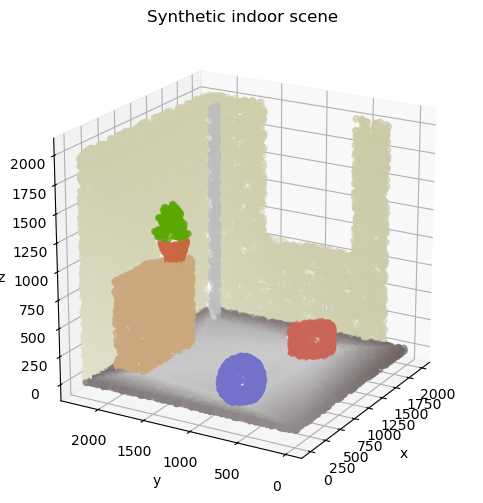

In [2]:
# Plot original pointcloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_box_aspect([1, 1, 1]) # equal aspect ratio
ax.view_init(elev=20, azim=210) # adjust the view angle
ax.set_title("Synthetic indoor scene")
plt.show()


## Eigenvalue-based Features

As introduced in the previous notebook, the decomposition of the covariance matrix computed over a local neighborhood is a fundamental tool for estimating the local tangent plane. From this analysis, geometric quantities such as surface normals  and curvature proxies can be derived \cite{hoppe1992surface, pauly2002efficient}.

Given a point $p_{i}$​ and its neighborhood $N_{i}$​, the local covariance matrix is defined as:

\begin{equation*}
    cov_{i} = \frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} (p_j - c_i) \cdot (p_j - c_i)^{T}
\end{equation*}

where $c_{i}$ denotes the centroid of the neighborhood:

\begin{equation*}
    c_{i} = \frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} p_j
\end{equation*}

The eigen-decomposition of this matrix yields three eigenvalues $\lambda_{1}^{i} \geq \lambda_{2}^{i} \geq \lambda_{3}^{i} \geq 0$, along with their associated eigenvectors.

The eigenvector $\nu_{3}^{i}$ associated with the smallest eigenvalue $\lambda_{3}^{i}$ provides an estimate of the surface normal $n_{i}$ and the ratio between this smallest eigenvalue and the sum of eigenvalues, also called *curvature change*:

\begin{equation*}
    C_{\lambda}^{i} = \frac{\lambda_{3}^{i}}{\lambda_{1}^{i} + \lambda_{2}^{i} + \lambda_{3}^{i}}
\end{equation*}

is commonly used as a measure of local surface variation, often interpreted as a curvature proxy.

**Eigenvalue-based features extend this analysis by exploiting the relative magnitudes of the eigenvalues to characterize the local geometric structure**. Instead of focusing solely on normal estimation, they describe how the point distribution is organized in the neighborhood of $p_{i}$.

A useful way to interpret these quantities is through the ellipsoid defined by the covariance matrix. The principal axes of this ellipsoid correspond to the eigenvectors, while their lengths are proportional to the square roots of the eigenvalues. This representation provides an intuitive geometric interpretation: for example, if two eigenvalues dominate, the neighborhood lies close to a plane, indicating a planar structure. However, note that it is not strictly equivalent to fitting the ellipsoid to the points and its size is arbitrary.

In [3]:
def compute_ellipsoid(points):
    """Compute the ellipsoid from the points."""

    # Center pointcloud
    centroid = points.mean(axis=0)
    centered_points = points - centroid
    # Covariance matrix
    cov = (centered_points.T @ centered_points) / len(points)
    # Eigen decomposition (eigenvalues are in ascending order here!)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Create ellipsoid mesh
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ellipsoid = np.array([x, y, z])
    # Scale by eigenvalues
    for i in range(3):
        ellipsoid[i] *= np.sqrt(eigenvalues[i])
    # Rotate by eigenvectors
    ellipsoid_rotated = np.tensordot(eigenvectors, ellipsoid.reshape(3, -1),
                                     axes=(1, 0))
    ellipsoid_rotated = ellipsoid_rotated.reshape(3, 50, 50)
    # Translate by centroid
    ellipsoid_rotated += centroid[:, np.newaxis, np.newaxis]
    
    return centroid, eigenvalues, eigenvectors, ellipsoid_rotated


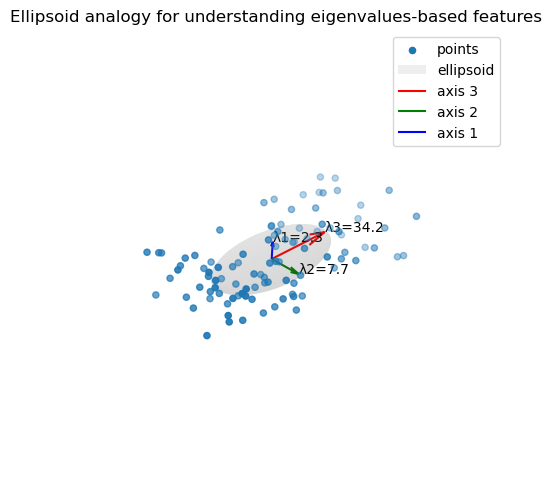

In [4]:
# Generate random 3D points
random_points = np.random.random((100, 3))
random_points *= np.array([20, 10, 5]) # adjust the scale
# Compute ellipsoid and principal axes
mean, eigvalues, eigvectors, ellipsoid = compute_ellipsoid(random_points)

# Plot points and ellipsoid
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
           label="points")
ax.plot_surface(ellipsoid[0], ellipsoid[1], ellipsoid[2],
                color="grey", alpha=0.1, label="ellipsoid")
for i, c in enumerate(["red", "green", "blue"]):
    j = 2 - i # to be consistent with eigenvalue ordering (smallest to largest)
    axis_vector = np.sqrt(eigvalues[j]) * eigvectors[:, j]
    ax.quiver(mean[0], mean[1], mean[2],
              axis_vector[0], axis_vector[1], axis_vector[2], 
              color=c, length=1., label=f"axis {j+1}")
    ax.text(mean[0] + axis_vector[0],
            mean[1] + axis_vector[1],
            mean[2] + axis_vector[2],
            f"λ{j+1}={eigvalues[j]:.1f}", color="black")
ax.set_title("Ellipsoid analogy for understanding eigenvalues-based features")
ax.set_axis_off()
ax.view_init(30, 45)
plt.legend()
plt.axis("equal")
plt.show()


This ellipsoid analogy provides an intuitive understanding of the local geometry around each point and motivates the definition of the features described below.

| Feature             | Formula                                                             | Intuitive meaning                                  |
|:--------------------|:--------------------------------------------------------------------|:---------------------------------------------------|
| Linearity           | $L_{\lambda} = \frac{\lambda_1 - \lambda_2}{\lambda_1}$             | Degree of elongation (1D structure)                |
| Planarity           | $P_{\lambda} = \frac{\lambda_2 - \lambda_3}{\lambda_1}$             | Degree of flatness (2D structure)                  |
| Scattering          | $S_{\lambda} = \frac{\lambda_3}{\lambda_1}$                         | Degree of volumetric dispersion (3D structure)     |
| Omnivariance        | $O_{\lambda} = (\lambda_1 \lambda_2 \lambda_3)^{\frac{1}{3}}$       | Overall spread in all directions                   |
| Anisotropy          | $A_{\lambda} = \frac{\lambda_1 - \lambda_3}{\lambda_1}$             | Difference between strongest and weakest variation |
| Eigenentropy        | $E_{\lambda} = \sum_{i=1}^{3} - \lambda_i \ln(\lambda_i)$           | Degree of disorder in the distribution             |
| Sum of eigenvalues  | $\Sigma_{\lambda} = \lambda_1 + \lambda_2 + \lambda_3$              | Total variance (scale-dependent)                   |
| Change of curvature | $C_{\lambda} = \frac{\lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}$ | Degree of bending (curvature proxy)                |

Scattering is also commonly referred to as *sphericity*, as it reflects the isotropy of the neighborhood.

In practice, a small subset of these features is sufficient for many tasks. In particular, linearity, planarity, scattering (sphericity), and change of curvature are the most widely used, as they provide a compact and discriminative description of local shape. These are represented below.

Eigenvalue-based features are simple, interpretable, and computationally efficient, making them well suited for large-scale pointclouds. However, they are sensitive to the choice of neighborhood scale and can be affected by noise and variations in point density.

These implementations below compute the $k$ nearest neighbors for all points at once and use vectorized operations whenever possible instead of explicit loops. While improving execution speed, it is also memory-intensive and switching to batch processing is advised for large pointclouds.

In [5]:
def compute_3D_eigen_features(points, neighbor_finder, norm_eigenvalues=False):
    """Compute local eigenvalue-based features."""

    # Neighbors for all query points
    inds = neighbor_finder(points) # (N, k)
    k = inds.shape[-1]
    neighbors = points[inds]
    # Eigenvalues from covariance matrix
    neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
    cov = (neighbors.transpose(0, 2, 1) @ neighbors) / k  # (N, 3, 3)
    eigenvalues = np.linalg.eigvalsh(cov) # (N, 3)
    eigenvalues = np.clip(eigenvalues, 1e-10, None) # fix numerical negatives
    # Compute sum before normalization (equal to 1. if normalized)
    eigensum = eigenvalues.sum(axis=1)
    # Normalize eigenvalues if required
    if norm_eigenvalues:
        eigenvalues /= eigenvalues.sum(axis=1, keepdims=True)
    # Compute features based on eigenvalues
    lambda_1 = eigenvalues[:, 2]
    lambda_2 = eigenvalues[:, 1]
    lambda_3 = eigenvalues[:, 0]
    linearity = (lambda_1 - lambda_2) / lambda_1
    planarity = (lambda_2 - lambda_3) / lambda_1
    scattering = lambda_3 / lambda_1
    omnivariance = (lambda_1 * lambda_2 * lambda_3) ** (1/3)
    anisotropy = (lambda_1 - lambda_3) / lambda_1
    eigentropy = -np.sum(eigenvalues * np.log(eigenvalues), axis=1)
    curvature = lambda_3 / (lambda_1 + lambda_2 + lambda_3)

    return (linearity, planarity, scattering, omnivariance, anisotropy,
            eigentropy, eigensum, curvature)


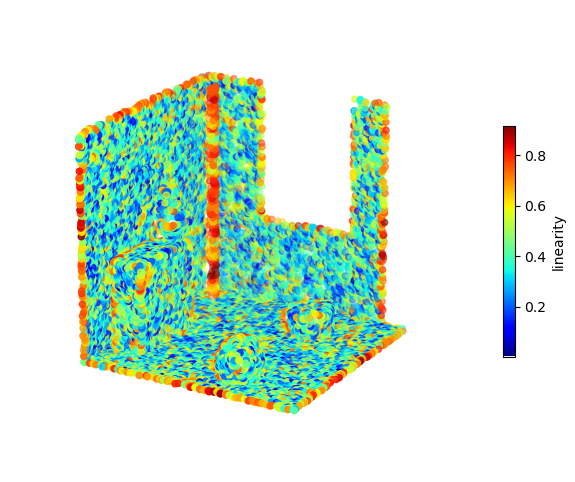

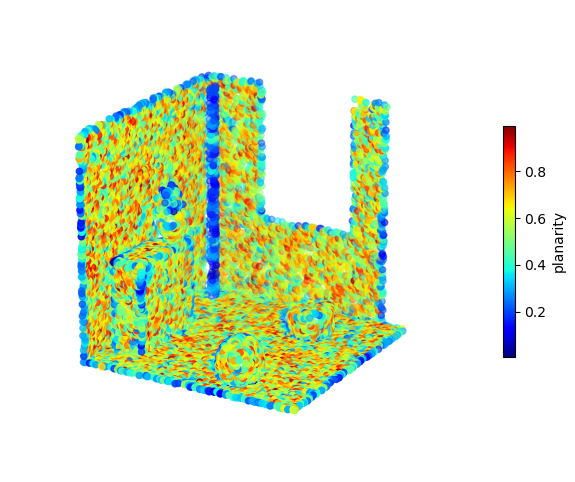

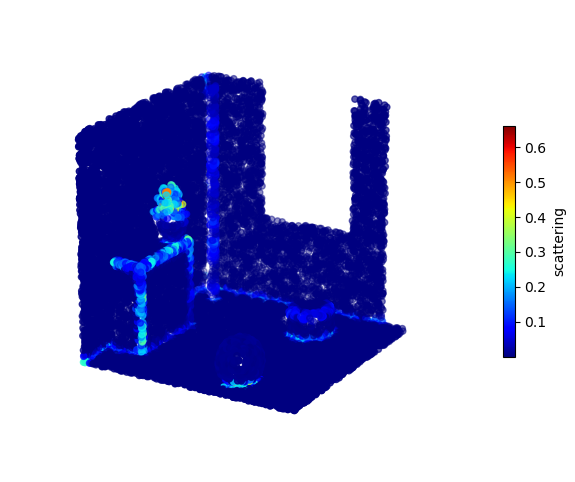

In [ ]:
# Compute local 3D features
neighbor_finder = lambda points: kdtree.query(points, 20)[1]
eigenfeatures = compute_3D_eigen_features(points, neighbor_finder, True)

# Visualize linearity, planarity and scattering
for feature_name, feature in zip(
        ["linearity", "planarity", "scattering"],
        eigenfeatures[:3]
    ):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    im = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                    c=feature, cmap='jet')
    cbar = fig.colorbar(im, ax=ax, shrink=0.5)
    cbar.set_label(feature_name)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(20, 210)
    ax.set_axis_off()
plt.show()


## Point Feature Histograms (PFH) and Fast Point Feature Histograms (FPFH)

Local descriptors such as eigenvalue-based features characterize the geometry around a point, but they do not explicitly encode relationships between neighboring points. Point Feature Histograms (PFH) were introduced by Radu Bogdan Rusu (one of the main contributors behind the Point Cloud Library ```PCL```) to address this limitation \cite{rusu2010semantic}. **The main idea behind PFH is to capture *pairwise geometric relationships* within a local neighborhood using both point coordinates and normals**. 

More specifically, **PFH aggregates geometric interactions between neighboring points into a multi-dimensional histogram representation**. Unlike simpler descriptors, which summarize point-wise properties independently, PFH encode how points relate to one another, leading to a richer description of the underlying surface structure.

The PFH computation algorithm can be summarized in a few steps:

For each point $p_i$ with normal $n_{i}$ of the pointcloud:

1. Query its neighbors $p_j$ within a radius $r$ (or alternatively its $k$-nearest neighbors).

2. Form all possible pairs $(p_{j}, p_{k})$ within this neighborhood.

3. Define a local reference frame for each pair, consisting of a source point and target point $(p_{s}, p_{t})$, using the normal of the source point $n_{s}$, such as:
\begin{equation*}
    u = n_{s} \qquad v = \frac{(p_{t} - p_{s} \times u)}{|| (p_{t} - p_{s} \times u) ||} \qquad w = u \times v
\end{equation*}

4. Compute angular features $(\alpha, \phi, \theta)$ and distance $d$ for each pair $(p_{s}, p_{t})$, such as:
\begin{equation*}
    \alpha = v \cdot n_{t} \qquad \phi = u \cdot \frac{p_{t} - p_{s}}{|| p_{t} - p_{s} ||} \qquad \theta = \arctan (w \cdot n_{t}, u \cdot n_{t})
\end{equation*}

\begin{equation*}
    d = || p_{t} - p_{s} ||
\end{equation*}

5. Discretize these features $(\alpha, \phi, \theta, d)$ and accumulate them into a 4D-histogram, which is normalized so it is independent of the number of neighbors.

The resulting normalized histogram represents the PFH descriptor of $p_{i}$.

A crucial aspect of PFH is that **it captures the joint distribution of all features**. This means that PFH does not build four independent histograms, but a single multi-dimensional histogram (a bin represents statements like: *"the pair has a small $\alpha$, medium $\phi$, large $\theta$, and medium distance"*). This joint encoding is what allows PFH to capture rich geometric relationships between points.

In practice, the distance term $d$ is often omitted or treated separately. Most implementations (including the one found in ```PCL```) focus primarily on the angular features $(\alpha, \phi, \theta)$. These angular features are naturally bounded within fixed intervals ($[-1, 1]$ for $\alpha$ and $\phi$ and $[-\pi, \pi]$ for $\theta$), which makes them well-suited for consistent discretization (whereas distance can vary significantly depending on pointcloud scale and neighborhood selection).

**The main drawback of PFH is its high computational complexity**. Indeed, it requires evaluating all pairwise interactions within the neighborhood, resulting in $O(k^{2})$ operations per point, where $k$ is the number of neighbors. While being rotation-invariant, PFH is still sensitive to errors in normal estimation, noise and outliers. It is also dependent on the neighborhood type and size.

Below is an example of a PFH for a given point of our pointcloud.


In [7]:
def compute_PFH(points, normals, neighbor_finder, num_bins=5,
                normalize_histogram=True):
    """Compute Point Feature Histograms (PFH) for each point."""
    
    N, _ = points.shape
    # 3D histogram of angular features (alpha, phi, theta) put together
    pfh = np.zeros((N, num_bins ** 3), dtype=float)
    
    for i in range(N):
        neighbors = neighbor_finder(points[i])
        features = []
        # Pairwise combinations of neighbors (without repetition)
        for (ind_s, ind_t) in combinations(neighbors, 2): # from itertools
            p_s, n_s = points[ind_s], normals[ind_s]
            p_t, n_t = points[ind_t], normals[ind_t]
            alpha, phi, theta, _ = compute_PFH_features(p_s, n_s, p_t, n_t)
            features.append([alpha, phi, theta])
        # Convert to numpy array and handle case with no valid pairs
        if features:
            features = np.array(features)
        else:
            continue # if no valid pairs, skip this point
        # 3D histogram of angular features (alpha, phi, theta)
        histogram, _ = np.histogramdd(
            features,
            bins=num_bins,
            range=[[-1., 1.], [-1., 1.], [-np.pi, np.pi]],
        )
        histogram = histogram.flatten() # get a 1D descriptor vector
        # Normalize histogram
        if normalize_histogram:
            histogram /= histogram.sum()

        pfh[i] = histogram

    return pfh


def compute_PFH_features(p_s, n_s, p_t, n_t):
    """Compute features (alpha, phi, theta, dist) for a pair of points."""
    
    diff = p_t - p_s
    dist = np.linalg.norm(diff)
    #if dist < 1e-10:
    diff_unit = diff / dist
    u = n_s
    v = np.cross(diff_unit, u)
    v_norm = np.linalg.norm(v)
    #if v_norm < 1e-10:
    v /= v_norm
    w = np.cross(u, v)
    alpha = v @ n_t
    phi = u @ diff_unit
    theta = np.arctan2((w @ n_t), (u @ n_t))
    
    return alpha, phi, theta, dist

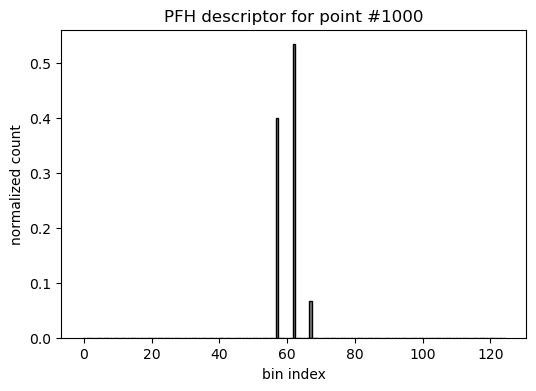

In [8]:
# Compute PFH descriptors
neighbor_finder = lambda point: kdtree.query_ball_point(point, 25.)
pfh_descriptors = compute_PFH(points, normals, neighbor_finder, num_bins=5)

# PFH angular descriptors associated with a point
i = 1000 # index of the point to visualize
descriptor = pfh_descriptors[i]

# Plot as a bar graph
plt.figure(figsize=(6, 4))
plt.bar(range(len(descriptor)), descriptor, color="gray", edgecolor="black")
plt.xlabel("bin index")
plt.ylabel("normalized count")
plt.title(f"PFH descriptor for point #{i}")
plt.show()


The high computational cost of Point Feature Histograms often make them difficult to apply to very large pointclouds or real-time applications. To overcome this computational limitations of PFH, Fast Point Feature Histograms (FPFH) were later introduced as an efficient approximation of the original descriptor \cite{rusu2010semantic}. 

**FPFH retain the core idea of encoding local geometry through angular relationships between points and normals, but does not consider all pairwise interactions within a neighborhood**. Instead , FPFH decompose the process into two stages: 

1. Compute *Simplified Point Feature Histograms* (SPFH), containing angular features and distance $(\alpha, \phi, \theta, d)$, between each point $p_{i}$ and its $k$ immediate neighbors $p_{j}$.

2. Aggregate these local signatures using a distance‑based weighting scheme:
\begin{equation*}
    FPFH(p_{i}) = SPFH(p_{i}) + \frac{1}{k} \sum^{k-1}_{j=0} \frac{1}{\omega_{j}} SPFH(p_{j})
\end{equation*}
where the weight $\omega_{j}$ is usually the distance between $p_{i}$ and $p_{j}$.

This approximation reduces the complexity from $O(k^{2})$ to $O(k)$ per point while preserving most of the discriminative power of PFH.

**One major difference with PFH is that FPFH builds independent histograms for each angular feature rather than a fully joint multi-dimensional distribution**. This also results in a more compact descriptor, commonly a 33-dimensional vector. The weighting scheme allows FPFH to implicitly capture a broader neighborhood influence, partially compensating for the loss of direct pairwise combinations.

As a result, FPFH provides a good trade‑off between descriptiveness and efficiency, making it widely used in practical applications such as real‑time registration.

Below is the FPFH for the same point of our pointcloud.

In [9]:
def compute_FPFH(points, normals, neighbor_finder, num_bins=11,
                 normalize_histogram=True):
    """Compute Fast Point Feature Histograms (FPFH) for each point."""
    
    N, _ = points.shape
    # 1D histogram of angular features (alpha, phi, theta) put together
    fpfh = np.zeros((N, num_bins * 3), dtype=float) 
    # SPFH for each point (to be averaged for neighbors)
    spfh = np.zeros((N, num_bins * 3), dtype=float)
    
    for i in range(N):
        neighbors = neighbor_finder(points[i]) # point itself included
        neighbors = [ind for ind in neighbors if ind != i] # exclude point
        features = []
        for ind in neighbors:
            p_s, n_s = points[i], normals[i]
            p_t, n_t = points[ind], normals[ind]
            alpha, phi, theta, _ = compute_PFH_features(p_s, n_s, p_t, n_t)
            features.append([alpha, phi, theta])
        # Convert to numpy array and handle case with no valid neighbors
        if features:
            features = np.array(features)
        else:
            continue # if no valid neighbors, skip this point
        # 1D histograms of angular features (alpha, phi, theta) put together
        hist_alpha, _ = np.histogram(features[:, 0], bins=num_bins, 
                                     range=(-1., 1.))
        hist_phi, _ = np.histogram(features[:, 1], bins=num_bins, 
                                   range=(-1., 1.))
        hist_theta, _ = np.histogram(features[:, 2], bins=num_bins,
                                     range=(-np.pi, np.pi))
        histogram = np.concatenate([hist_alpha, hist_phi, hist_theta],
                                   dtype=float) # for normalization
        if normalize_histogram:
            histogram /= histogram.sum()
        spfh[i] = histogram

    # Average SPFH of neighbors to get FPFH
    for i in range(N):
        fpfh[i] = spfh[i]
        # Contribution of neighbors
        neighbors = neighbor_finder(points[i]) # point itself included
        neighbors = [ind for ind in neighbors if ind != i] # exclude point
        if neighbors:
            # Weights based on distances (but alternives are possible)
            dists = np.linalg.norm(points[neighbors] - points[i], axis=1)
            weights = 1. / (dists + 1e-10) # inverse distance weights
            contribs = 1./len(neighbors) * weights[:, None] * spfh[neighbors]
            fpfh[i] += np.sum(contribs, axis=0)
        else:
            continue # if no neighbors, FPFH is just SPFH

    return fpfh

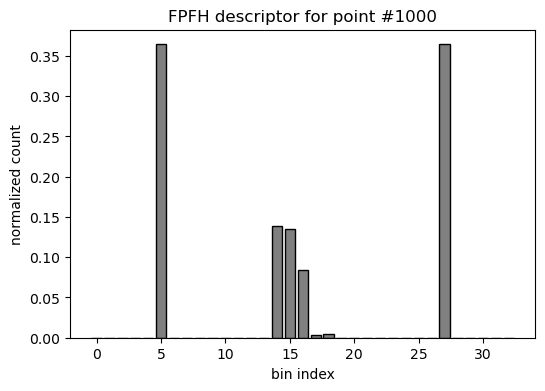

In [10]:
# Compute FPFH descriptors
neighbor_finder = lambda point: kdtree.query_ball_point(point, 25.)
fpfh_descriptors = compute_FPFH(points, normals, neighbor_finder, num_bins=11)

# FPFH angular descriptors associated with a point
i = 1000 # index of the point to visualize
descriptor = fpfh_descriptors[i]

# Plot as a bar graph
plt.figure(figsize=(6, 4))
plt.bar(range(len(descriptor)), descriptor, color="gray", edgecolor="black")
plt.xlabel("bin index")
plt.ylabel("normalized count")
plt.title(f"FPFH descriptor for point #{i}")
plt.show()


## Signature of Histograms of OrienTations (SHOT)

SHOT was motivated by the observation that geometric signatures (such as eigenvalue-based features) are often discriminative but sensitive to noise and unstable reference frames, whereas histogram-based methods (such as PFH) are more robust but less distinctive. SHOT addresses this trade-off by combining both ideas by introducing a repeatable local reference frame (LRF) \cite{tombari2010unique}.

**The core idea of SHOT is to describe the local geometry around a point by expressing its neighborhood in a stable local coordinate system and capturing the spatial distribution of normals**. The neighborhood is partitioned into spatial regions, and in each is built a **histogram of normal orientations**. By concatenating these histograms, SHOT aims to capture both the spatial arrangement and the geometric properties of the sampled surface.

The construction of the SHOT descriptor for a given point $p_{i}$ follows these principal steps:

1. Query the neighbors of $p_{i}$ within radius $r$ and form the set $N_{i}$.

2. Compute a weighted covariance-like matrix:
\begin{equation*}
    M_{i} = \frac{1}{\sum_{p_{j} \in N_{i}} (r - d_{j})} \sum_{p_{j} \in N_{i}} (r - d_{j}) (p_{j} - p_{i}) \cdot (p_{j} - p_{i})^{T}
\end{equation*}
with $d_{j} = || p_{j} - p_{i} ||$.
Its eigen-decomposition yields eigenvectors $(\nu_{1}, \nu_{2}, \nu_{3})$ and eigenvalues $\lambda_{1} \geq \lambda_{2} \geq \lambda_{3}$.

3. Disambiguate the directions of eigenvectors to obtain the axes $(u, v, w)$ of the LRF:
\begin{equation*}
    u = \text{sign} (S_{x}) \nu_{1} \quad \text{with} \quad S_{x} = \sum_{p_{j} \in N_{i}} (p_{j} - p_{i}) \cdot \nu_{1}
\end{equation*}
and
\begin{equation*}
    w = \text{sign} (S_{z}) . \nu_{3} \quad \text{with} \quad S_{z} = \sum_{p_{j} \in N_{i}} (p_{j} - p_{i}) \cdot \nu_{3}
\end{equation*}
and
\begin{equation*}
    v = w \times u
\end{equation*}

4. Project each neighbor $p_{j}$ into the LRF:
\begin{equation*}
    q_{j} = \begin{pmatrix} (p_{j} - p_{i}) \cdot u \\ (p_{j} - p_{i}) \cdot v \\ (p_{j} - p_{i}) \cdot w \end{pmatrix}
\end{equation*}

5. Partition the support region into 3D spatial bins based on radial distance $\rho$, azimuth $\phi$ and elevation angle $\psi$ (with respect to $w$). Each point $p_{j}$ is associated with a bin indexed by $(\rho_{j}, \phi_{j} \psi_{j})$ such as:
\begin{equation*}
    \rho_{j} = || q_{j} ||
\end{equation*}
and
\begin{equation*}
    \phi_{j} = \arctan2((p_{j} - p_{i}) \cdot v,  (p_{j} - p_{i}) \cdot u)
\end{equation*}
and
\begin{equation*}
    \psi_{j} = \arccos((p_{j} - p_{i}) \cdot w / || q_{j} ||)
\end{equation*}

6. Compute the angle each neighbor normal $n_{j}$ and the $w$ axis of the LRF:
\begin{equation*}
    \theta_{j} = n_{j} \cdot w
\end{equation*}

7. Accumulate these values into histograms within each spatial bin using quadrilinear interpolation in the 4D space $(\rho, \phi, \psi, \theta)$. The contribution of $p_{j}$ is split among adjacent bins with weights $\omega_{\rho}$, $\omega_{\phi}$, $\omega_{\psi}$ and $\omega_{\theta}$ proportional to its distance from the bin centers.

8. Concatenate the histograms of angles $\theta$ (one per spatial bin) into a single feature vector and normalize it.


The first three steps can be grouped into the **computation of the Local Reference Frame (LRF)**, which is one of the key contributions of SHOT.

This LRF is derived from the eigen-analysis of the local neighborhood, previously introduced for normal estimation and eigenvalue-based features computations. SHOT proposes to improve the classic formulation in two ways: it assigns lower weights to distant neighbors and replaces the neighborhood centroid with the point of interest. It is important to note that, unlike in classical normal estimation, the eigenvector $\nu_{3}$ associated with the smallest eigenvalue $\lambda_{3}$ does not necessarily correspond to the surface normal.

A key issue is that eigenvectors are defined up to a sign, which leads to ambiguity in the LRF. SHOT resolves this by enforcing a consistent orientation based on the spatial distribution of neighboring points. For each axis, the sign is chosen such that the majority of neighbors lie in corresponding the positive half-space. This is supposed to yield a unique and repeatable LRF, which is essential for robust descriptor computation.

In [11]:
def local_reference_frame(point, neighbors, radius):
    """Compute local reference frame for each point."""
    
    # Center the neighbors and compute distances
    diffs = neighbors - point
    dists = np.linalg.norm(diffs, axis=1)
    # Compute and normalize weights (based on distance)
    weights = radius - dists
    weights /= (weights.sum() + 1e-12)
    # Compute weighted covariance matrix
    cov = (diffs * weights[:, None]).T @ diffs
    # Decompose covariance matrix
    _, eigenvectors = np.linalg.eigh(cov) # eigenvalues are in ascending order
    x_axis = eigenvectors[:, 2] # largest eigenvalue
    z_axis = eigenvectors[:, 0] # smallest eigenvalue
    # Sign disambiguation for consistent orientation
    projs = neighbors @ x_axis
    if np.sum(projs > 0) < np.sum(projs < 0):
        x_axis = -x_axis
    projs = neighbors @ z_axis
    if np.sum(projs > 0) < np.sum(projs < 0):
        z_axis = -z_axis
    # y-axis as cross product to ensure right-handed system
    y_axis = np.cross(z_axis, x_axis)
    y_axis /= (np.linalg.norm(y_axis) + 1e-12)
    
    return np.stack([x_axis, y_axis, z_axis], axis=1)


The last steps of SHOT focus on the **partitioning of the support region and the accumulation of local geometric information**. The neighborhood, expressed in the LRF, is subdivided into 3D spatial bins. Within each bin, a histogram of normal orientations is constructed, capturing the local surface geometry in a spatially structured manner.

In practice, the quality of the descriptor depends on several choices such as the number of spatial bins and the number of histogram bins. SHOT typically uses 32 spatial bins (2 radial, 8 azimuth and 2 elevation), each containing an 11-bin histogram, resulting in the widely used 352-dimensional descriptor.

In [12]:
def compute_SHOT(point, neighbors, normals, radius,
                 n_azimuth=8, n_elevation=2, n_radial=2, n_bins=11):

    # Compute LRF and project neighbors into it
    R = local_reference_frame(point, neighbors, radius)
    neighbors_projected = (neighbors - point) @ R
    dists = np.linalg.norm(neighbors_projected, axis=1)

    # Compute Gaussian spatial weighs
    sigma = radius / 2.0
    w_spatial = np.exp(-(dists**2) / (2 * sigma**2))

    # Compute continuous bin coordinates
    # Radial
    r = dists / radius * n_radial
    r0 = np.floor(r).astype(int)
    r1 = np.minimum(r0 + 1, n_radial - 1)
    wr = r - r0
    # Elevation (z direction)
    z = neighbors_projected[:, 2] / (dists + 1e-12)
    e = (z + 1) * 0.5 * n_elevation
    e0 = np.floor(e).astype(int)
    e1 = np.minimum(e0 + 1, n_elevation - 1)
    we = e - e0
    # Azimuth (angle in xy plane)
    angles = np.arctan2(neighbors_projected[:, 1], neighbors_projected[:, 0])
    a = (angles + np.pi) / (2*np.pi) * n_azimuth
    a0 = np.floor(a).astype(int) % n_azimuth
    a1 = (a0 + 1) % n_azimuth
    wa = a - np.floor(a)
    # Orientation (normal vs LRF z-axis)
    cos_theta = normals @ R[:, 2]
    h = (cos_theta + 1) * 0.5 * n_bins
    h0 = np.floor(h).astype(int)
    h1 = np.minimum(h0 + 1, n_bins - 1)
    wh = h - h0

    # Stack interpolation components
    r_idx = np.stack([r0, r1], axis=1)
    e_idx = np.stack([e0, e1], axis=1)
    a_idx = np.stack([a0, a1], axis=1)
    h_idx = np.stack([h0, h1], axis=1)

    w_r = np.stack([1-wr, wr], axis=1)
    w_e = np.stack([1-we, we], axis=1)
    w_a = np.stack([1-wa, wa], axis=1)
    w_h = np.stack([1-wh, wh], axis=1)

    # Broadcast to all 16 combinations
    weights = (w_r[:, :, None, None, None] *
               w_e[:, None, :, None, None] *
               w_a[:, None, None, :, None] *
               w_h[:, None, None, None, :])

    # Apply spatial weighting
    weights *= w_spatial[:, None, None, None, None]
    rr = r_idx[:, :, None, None, None]
    ee = e_idx[:, None, :, None, None]
    aa = a_idx[:, None, None, :, None]
    hh = h_idx[:, None, None, None, :]

    # Flatten
    # Force full broadcasting to same shape
    rr, ee, aa, hh, weights = np.broadcast_arrays(rr, ee, aa, hh, weights)

    # Now flatten safely
    rr = rr.ravel()
    ee = ee.ravel()
    aa = aa.ravel()
    hh = hh.ravel()
    weights = weights.ravel()

    # Convert to sector index
    sector = rr + n_radial * (ee + n_elevation * aa)
    n_sectors = n_radial * n_elevation * n_azimuth
    descriptor = np.zeros((n_sectors, n_bins))

    # Accumulate contributions
    np.add.at(descriptor, (sector, hh), weights)

    # Normalize descriptor
    descriptor = descriptor.ravel()
    descriptor /= (np.linalg.norm(descriptor) + 1e-12)

    return descriptor


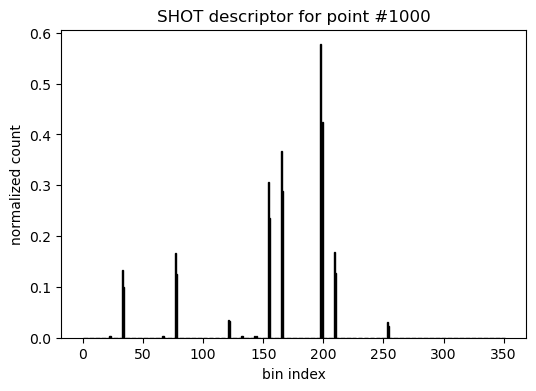

In [13]:
# Compute SHOT descriptor associated with a point
i = 1000 # index of the point to visualize
neighbor_finder = lambda point: kdtree.query_ball_point(point, 25.)
neighbor_inds = neighbor_finder(points[i])
descriptor = compute_SHOT(
    points[i], points[neighbor_inds], normals[neighbor_inds], radius=25.
)

# Plot as a bar graph
plt.figure(figsize=(6, 4))
plt.bar(range(len(descriptor)), descriptor, color="gray", edgecolor="black")
plt.xlabel("bin index")
plt.ylabel("normalized count")
plt.title(f"SHOT descriptor for point #{i}")
plt.show()


## Going further

Selecting an appropriate descriptor typically involves balancing expressiveness, robustness, and computational cost, and strongly depends on the target application. This notebook explored three representative families of descriptors widely used in practice: eigenvalue-based features, PFH, and SHOT.

Eigenvalue-based features are simple while still capturing meaningful geometric information, and are relatively inexpensive to compute. They can be obtained directly from local covariance analysis, either explicitly as in ```Open3D```, or implicitly as a by-product of normal estimation routines in libraries such as ```PCL``` and ```CGAL```. Their compact description of the local structure makes them particularly well suited for classification tasks such as semantic segmentation, where each point is assigned a semantic label. Typical applications include urban and natural scene understanding. In such context, eigenvalue-based features are often combined with additional geometric features derived directly from point coordinates, such as local point density and the deviation between the estimated normal and the vertical axis (often the $z$-axis) \cite{weinmann2015semantic}. This combination helps capture both intrinsic geometric properties and contextual information.

Histogram-based descriptors such as PFH and its faster variant FPFH provide a richer representation by encoding relationships within local neighborhoods. This makes them particularly suitable for matching and registration tasks, where reliable correspondences between pointclouds are required. Reference implementations are available in ```PCL```, through ```PFHEstimation``` and ```FPFHEstimation```. ```Open3D``` focuses on the more efficient FPFH only with ```compute_fpfh_feature```.

SHOT descriptors follow a similar objective, producing structured and highly discriminative signatures that are also widely used for matching and registration. Extensions of the original formulation incorporate color information, further improving distinctiveness in scenarios where geometric information alone is insufficient \cite{tombari2011combined}. ```PCL``` provides a reference implementation with ```SHOTEstimation``` and ```SHOTColorEstimation```.

Beyond the descriptors presented here, the landscape of 3D feature extraction remains active. Again, ```PCL``` includes both earlier approaches, such as Spin Images, and more recent descriptors like the *Viewpoint Feature Histogram* (VFH), which aggregates viewpoint-dependent information into global signatures \cite{johnson1997surface, rusu2010fast}. Such global descriptors are particularly useful for object-level recognition, rather than local matching.

More recent developments include learned descriptors, which have become a strong alternative to handcrafted features. The learning models are typically implemented in deep learning frameworks rather than classical geometry libraries. They learn task-specific representations directly from data and often outperform classical handcrafted descriptors in most applications. More broadly, the popularity of deep learning models illustrates a shift toward feature learning, where descriptors are no longer explicitly designed but instead learned directly from raw pointclouds. In practice, these techniques have not completely replaced handcrafted ones, as they typically require large training datasets and higher computational resources.

## Wrapping up

You should now have a better grasp of how to compute descriptors, also called features, that enrich each point with higher‑level geometric information. These descriptors go beyond normals and curvatures and provide a more expressive view of local geometry, enabling better analysis, classification, and interpretation complex 3D structures.

**Eigenvalue-based features** (such as *linearity*, *planarity* and *sphericity*) offer a compact and efficient way to characterize the local shape of a neighborhood. They are particularly well suited for tasks like segmentation and semantic labeling, where identifying structural patterns in the data is key. In contrast, histogram-based descriptors such as **FPFH** and **SHOT** capture richer spatial relationships by encoding the distribution of geometric interactions around a point. This makes them especially valuable for tasks such as registration and object recognition, where robustness and discriminative power are critical.

Together, these descriptors illustrate different trade-offs between simplicity, efficiency, and descriptive power, and form the basis of many practical pipelines in 3D pointcloud processing.

